In [2]:
import pandas as pd

file_path = r'/content/e-shop.csv'

data = pd.read_csv(file_path, sep=';')

data.columns = data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

data = data.sample(n=5000, random_state=42).reset_index(drop=True)

display(data.head())
data.info()

,year,month,day,order,country,session_id,page_1_main_category,page_2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,4,22,4,29,5279,4,P48,9,4,2,33,2,3
1,2008,5,19,1,29,10059,1,A15,14,5,2,33,2,1
2,2008,4,11,10,29,2919,4,P23,6,2,2,28,2,2
3,2008,4,28,3,27,6304,2,B24,11,2,1,57,1,2
4,2008,5,26,1,29,11266,1,A2,3,1,1,43,2,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   year                   5000 non-null   int64 
 1   month                  5000 non-null   int64 
 2   day                    5000 non-null   int64 
 3   order                  5000 non-null   int64 
 4   country                5000 non-null   int64 
 5   session_id             5000 non-null   int64 
 6   page_1_main_category   5000 non-null   int64 
 7   page_2_clothing_model  5000 non-null   object
 8   colour                 5000 non-null   int64 
 9   location               5000 non-null   int64 
 10  model_photography      5000 non-null   int64 
 11  price                  5000 non-null   int64 
 12  price_2                5000 non-null   int64 
 13  page                   5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


In [4]:
pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.7 MB/s eta 0:00:00


In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import sdv
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

data.columns = data.columns.str.strip().str.lower()
target_col = 'price'

data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
if 'session_id' in data.columns:
    data = data.drop(columns=['session_id'])
data = data.dropna(subset=[target_col]).reset_index(drop=True)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
metadata.update_column(column_name=target_col, sdtype='numerical')
for col in data.columns:
    if data[col].dtype == 'object':
        metadata.update_column(column_name=col, sdtype='categorical')

n_samples = len(data)

models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata, epochs=50, verbose=False),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata, epochs=50, verbose=False),
    "TVAE": TVAESynthesizer(metadata=metadata, epochs=50, verbose=False),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)

    synthetic_data = synthetic_data[data.columns]

    if target_col in synthetic_data.columns:
        synthetic_data[target_col] = pd.to_numeric(synthetic_data[target_col], errors='coerce')
        synthetic_data = synthetic_data.dropna(subset=[target_col])

    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(real_data=data, synthetic_data=synthetic_data, metadata=metadata)
    quality_report = evaluate_quality(real_data=data, synthetic_data=synthetic_data, metadata=metadata)

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    summary.append((name, diagnostic_report.get_score(), quality_report.get_score()))

summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())


Training CTGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 850.10it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 153.00it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 327.80it/s]|
Column Shapes Score: 89.62%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:00<00:00, 183.36it/s]|
Column Pair Trends Score: 48.25%

Overall Score (Average): 68.94%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 839.55it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 286.48it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 330.60it/s]|
Column Shapes Score: 86.93%

(2/2) Ev

,Model,Diagnostic Score,Quality Score
0,GaussianCopula,1.0,0.704185
1,CTGAN,1.0,0.689385
2,CopulaGAN,1.0,0.678292
3,TVAE,1.0,0.550731



Best model by quality score: GaussianCopula


,year,month,day,order,country,page_1_main_category,page_2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,5,5,6,24,2,A4,1,1,2,68,1,1
1,2008,7,18,5,20,4,A33,13,3,1,42,1,2
2,2008,8,28,5,34,4,A10,8,1,1,36,2,2
3,2008,6,28,2,30,1,C34,1,1,1,53,1,1
4,2008,4,21,2,20,1,C12,14,6,1,34,1,1


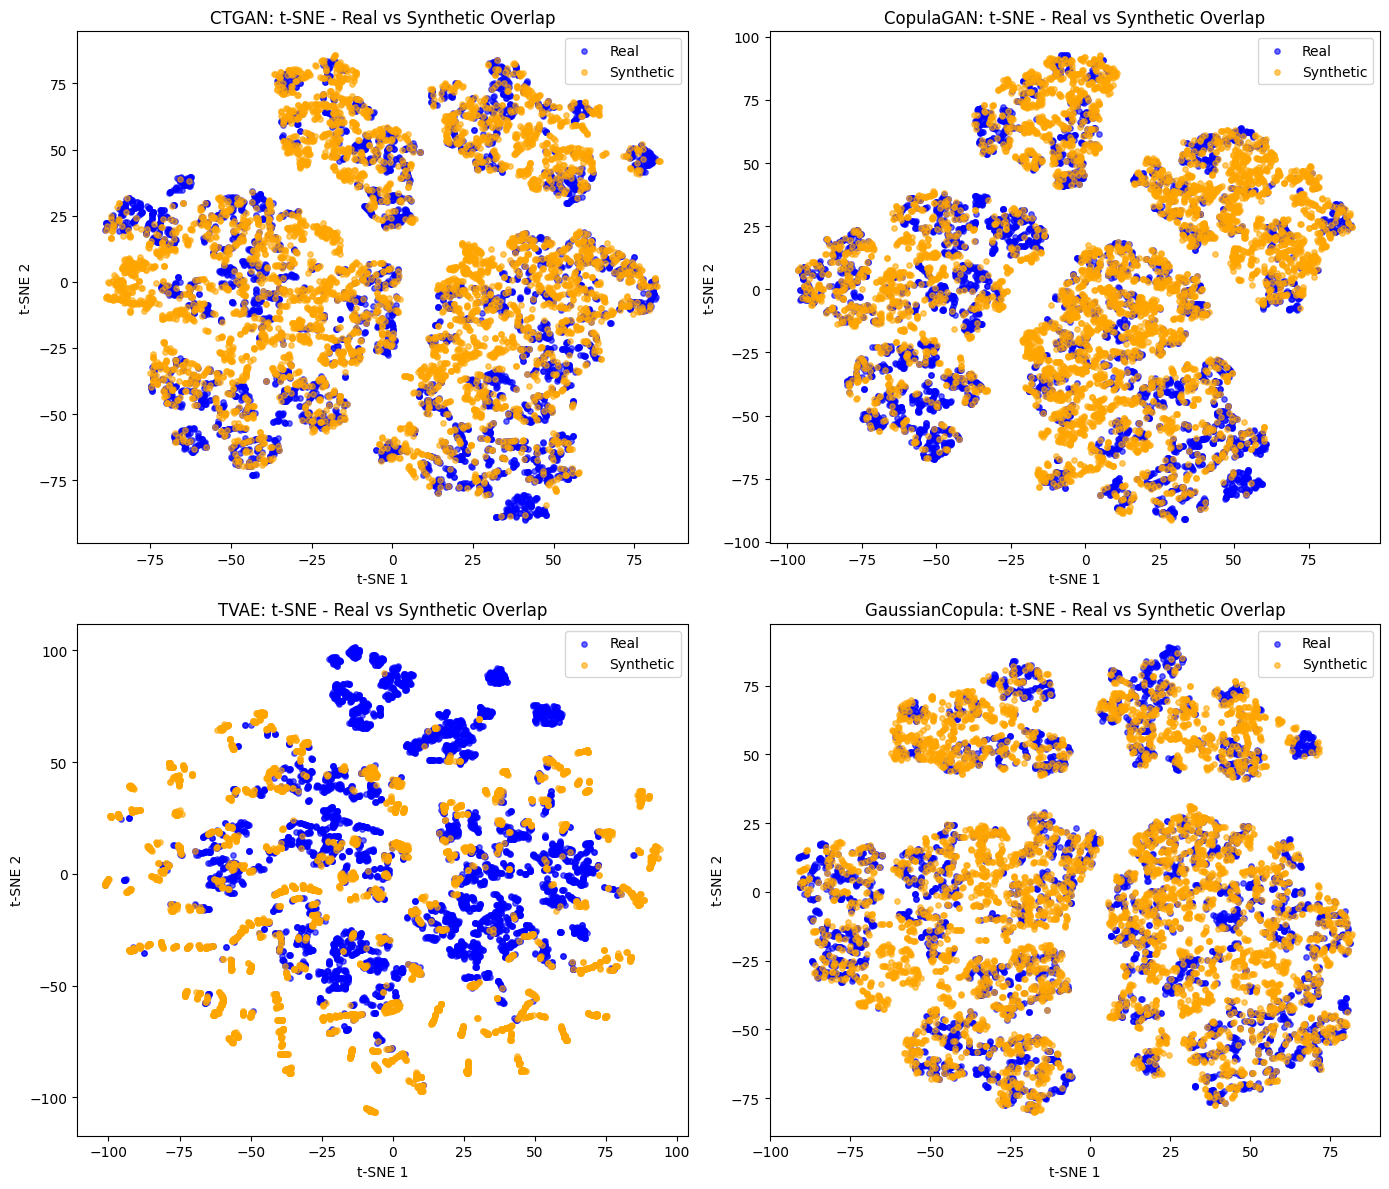

In [6]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_num),
    columns=feature_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns].copy()
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

In [7]:
! pip install umap-learn

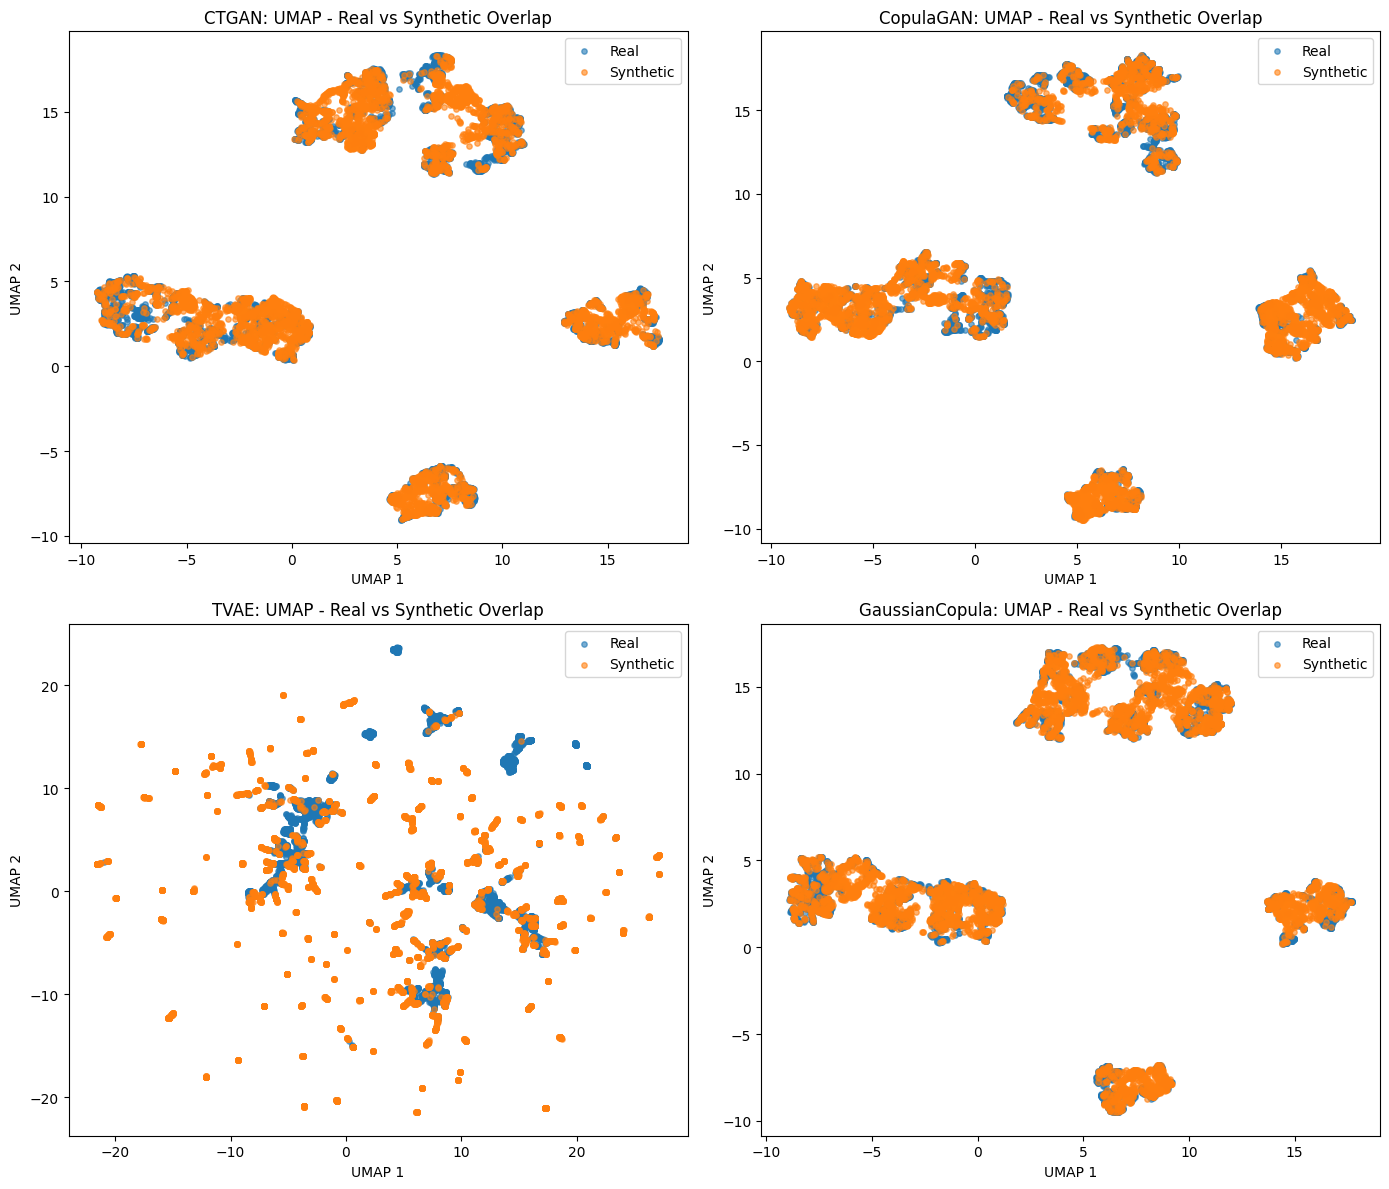

In [8]:
import umap.umap_ as umap
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "price"

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()

scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(real_num),
    columns=feature_cols
)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns].copy()
    synth_num = synth_df[feature_cols].copy()

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_num),
        columns=feature_cols
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    # --- UMAP instead of TSNE ---
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    umap_result = reducer.fit_transform(combined)

    ax.scatter(
        umap_result[labels == "Real", 0],
        umap_result[labels == "Real", 1],
        alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        umap_result[labels == "Synthetic", 0],
        umap_result[labels == "Synthetic", 1],
        alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: UMAP - Real vs Synthetic Overlap")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend()

plt.tight_layout()
plt.show()


=== Cluster Distribution (Real vs Synthetic) ===
Type     Real  Synthetic
Cluster                 
0        1226        780
1         949       1089
2        1132       1083
3         863       1187
4         830        861

=== Cluster Purity ===
Type         Real  Synthetic
Cluster                     
0        0.611167   0.388833
1        0.465653   0.534347
2        0.511061   0.488939
3        0.420976   0.579024
4        0.490834   0.509166

=== Feature Means per Cluster ===
         year     month       day     order   country  page_1_main_category  \
Cluster                                                                       
0         0.0  0.402792  0.406198  0.053150  0.567866              0.150881   
1         0.0  0.409102  0.374926  0.064023  0.590707              0.703795   
2         0.0  0.421896  0.382980  0.059051  0.575642              0.437923   
3         0.0  0.387805  0.358309  0.062489  0.592150              0.642927   
4         0.0  0.382318  0.392371  0.06

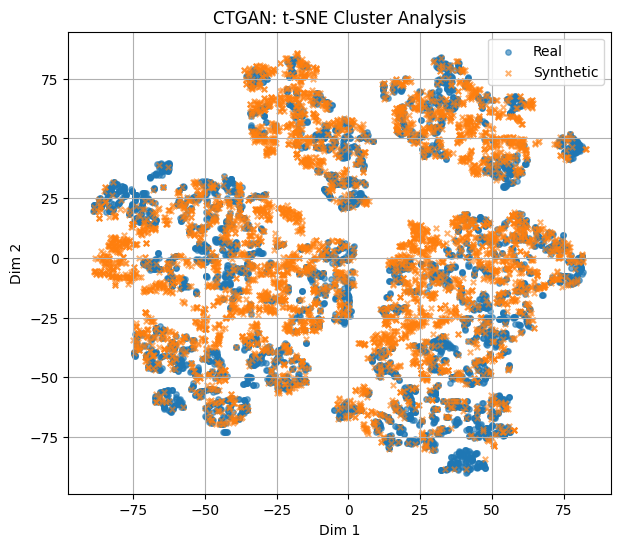

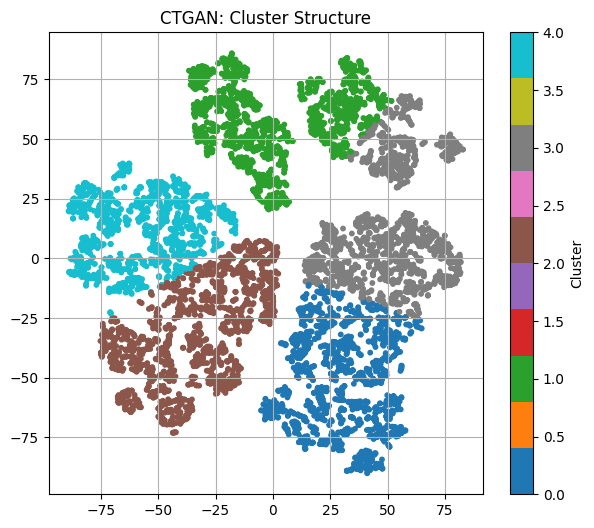

In [9]:
# ==============================
# FULL CLUSTER ANALYSIS PIPELINE
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.stats import wasserstein_distance

# ------------------------------
# SETTINGS
# ------------------------------
model_name = "CTGAN"   # change model here
target_col = "price"
n_clusters = 5         # tune based on your data

# ------------------------------
# PREPARE DATA
# ------------------------------
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()
synth_df = synthetic_datasets[model_name][data.columns].copy()
synth_num = synth_df[feature_cols].copy()

scaler = MinMaxScaler()

real_scaled = scaler.fit_transform(real_num)
synth_scaled = scaler.transform(synth_num)

# Combine
combined = np.vstack([real_scaled, synth_scaled])
labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synth_scaled))

# ------------------------------
# DIMENSION REDUCTION (t-SNE)
# ------------------------------
tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
embedding = tsne.fit_transform(combined)

# ------------------------------
# CLUSTERING
# ------------------------------
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(embedding)

# ------------------------------
# BUILD ANALYSIS DATAFRAME
# ------------------------------
combined_df = pd.DataFrame(combined, columns=feature_cols)
combined_df["Type"] = labels
combined_df["Cluster"] = clusters

# Add target back
combined_df[target_col] = pd.concat([
    data[target_col].reset_index(drop=True),
    synth_df[target_col].reset_index(drop=True)
], ignore_index=True)

# ------------------------------
# CLUSTER DISTRIBUTION
# ------------------------------
print("\n=== Cluster Distribution (Real vs Synthetic) ===")
cluster_counts = pd.crosstab(combined_df["Cluster"], combined_df["Type"])
print(cluster_counts)

print("\n=== Cluster Purity ===")
cluster_purity = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)
print(cluster_purity)

# ------------------------------
# FEATURE STATISTICS
# ------------------------------
print("\n=== Feature Means per Cluster ===")
cluster_means = combined_df.groupby("Cluster")[feature_cols].mean()
print(cluster_means)

# ------------------------------
# TARGET (PRICE) ANALYSIS
# ------------------------------
print("\n=== Target Distribution per Cluster ===")
price_summary = combined_df.groupby("Cluster")[target_col].describe()
print(price_summary)

# ------------------------------
# REAL vs SYNTH DIFFERENCE
# ------------------------------
real_df = combined_df[combined_df["Type"] == "Real"]
synth_df2 = combined_df[combined_df["Type"] == "Synthetic"]

real_means = real_df.groupby("Cluster")[feature_cols].mean()
synth_means = synth_df2.groupby("Cluster")[feature_cols].mean()

diff = (real_means - synth_means).abs()

print("\n=== Mean Difference (Real vs Synthetic) ===")
print(diff)

# ------------------------------
# WASSERSTEIN DISTANCE PER CLUSTER
# ------------------------------
print("\n=== Wasserstein Distance per Cluster ===")

wd_results = {}

for cluster in combined_df["Cluster"].unique():
    wd_cluster = {}

    real_cluster = real_df[real_df["Cluster"] == cluster]
    synth_cluster = synth_df2[synth_df2["Cluster"] == cluster]

    for col in feature_cols:
        if len(real_cluster) > 0 and len(synth_cluster) > 0:
            wd = wasserstein_distance(real_cluster[col], synth_cluster[col])
            wd_cluster[col] = wd

    wd_results[cluster] = wd_cluster

wd_df = pd.DataFrame(wd_results).T
print(wd_df)

# ------------------------------
# VISUALIZATION
# ------------------------------
plt.figure(figsize=(7,6))

for t, marker, alpha in zip(["Real", "Synthetic"], ["o", "x"], [0.6, 0.6]):
    idx = combined_df["Type"] == t
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        label=t,
        alpha=alpha,
        s=15,
        marker=marker
    )

plt.title(f"{model_name}: t-SNE Cluster Analysis")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# CLUSTER VISUALIZATION
# ------------------------------
plt.figure(figsize=(7,6))
plt.scatter(embedding[:,0], embedding[:,1], c=clusters, cmap="tab10", s=10)
plt.title(f"{model_name}: Cluster Structure")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


CLUSTER 0

--- Composition ---
Real samples      : 1779
Synthetic samples : 1631
Real %            : 0.52
Synthetic %       : 0.48

--- Sample Real Rows ---
   year  month       day     order   country  page_1_main_category    colour  \
4   0.0   0.25  0.833333  0.000000  0.604651              0.000000  0.153846   
5   0.0   0.75  0.233333  0.005435  0.604651              0.000000  0.153846   
6   0.0   0.00  0.500000  0.125000  0.604651              0.000000  0.230769   
7   0.0   0.00  0.833333  0.000000  0.604651              0.333333  0.384615   
8   0.0   0.00  0.933333  0.000000  0.604651              0.000000  0.538462   

   location  model_photography  price_2  page  Type  Cluster  price  
4       0.0                0.0      1.0  0.00  Real        0     43  
5       0.0                0.0      1.0  0.00  Real        0     43  
6       0.0                0.0      1.0  0.50  Real        0     38  
7       0.8                0.0      1.0  0.25  Real        0     38  
8       0.0

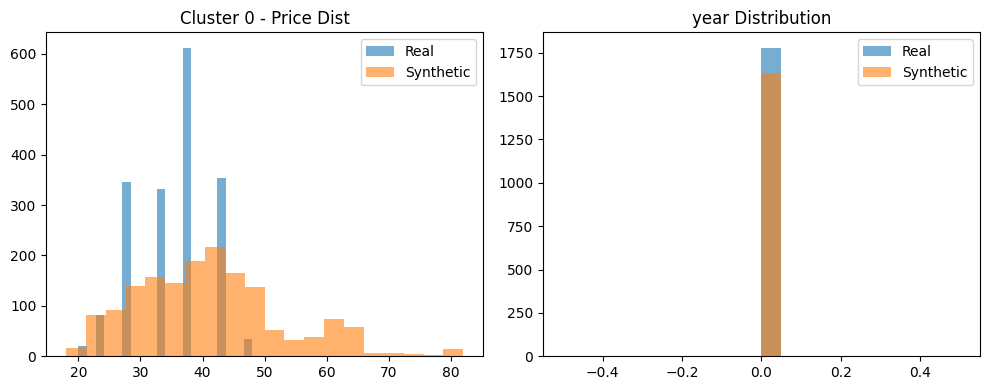


CLUSTER 1

--- Composition ---
Real samples      : 1096
Synthetic samples : 912
Real %            : 0.55
Synthetic %       : 0.45

--- Sample Real Rows ---
    year  month       day     order   country  page_1_main_category    colour  \
3    0.0   0.00  0.900000  0.010870  0.558140              0.333333  0.769231   
9    0.0   0.75  1.000000  0.000000  0.139535              0.000000  0.153846   
13   0.0   0.00  0.066667  0.000000  0.604651              0.333333  0.769231   
19   0.0   0.50  0.800000  0.005435  0.604651              0.000000  0.076923   
22   0.0   0.50  0.533333  0.021739  0.604651              0.000000  0.153846   

    location  model_photography  price_2  page  Type  Cluster  price  
3        0.2                0.0      0.0  0.25  Real        1     57  
9        0.4                0.0      0.0  0.00  Real        1     82  
13       0.2                0.0      0.0  0.25  Real        1     57  
19       0.6                0.0      0.0  0.25  Real        1     60  
2

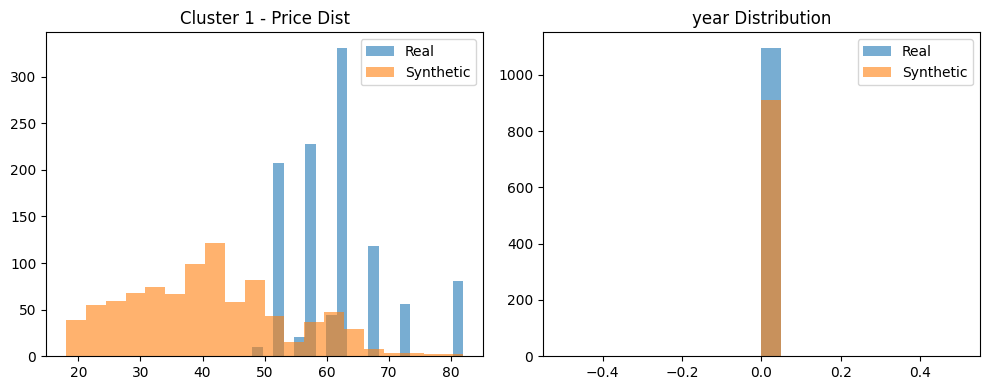


CLUSTER 2

--- Composition ---
Real samples      : 684
Synthetic samples : 724
Real %            : 0.49
Synthetic %       : 0.51

--- Sample Real Rows ---
    year  month       day     order   country  page_1_main_category    colour  \
0    0.0   0.00  0.700000  0.016304  0.604651                   1.0  0.615385   
1    0.0   0.25  0.600000  0.000000  0.604651                   0.0  1.000000   
2    0.0   0.00  0.333333  0.048913  0.604651                   1.0  0.384615   
16   0.0   0.00  0.633333  0.076087  0.604651                   1.0  0.230769   
20   0.0   0.00  0.966667  0.005435  0.604651                   0.0  1.000000   

    location  model_photography  price_2  page  Type  Cluster  price  
0        0.6                1.0      1.0  0.50  Real        2     33  
1        0.8                1.0      1.0  0.00  Real        2     33  
2        0.2                1.0      1.0  0.25  Real        2     28  
16       0.4                1.0      1.0  0.00  Real        2     28  
20

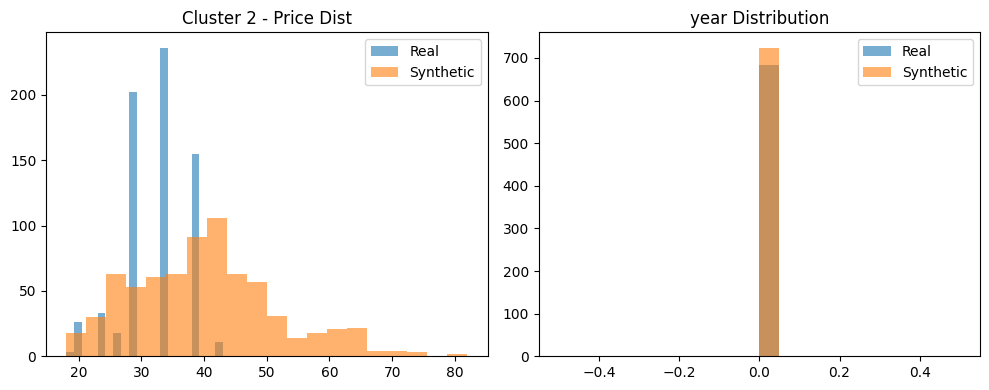


CLUSTER 3

--- Composition ---
Real samples      : 574
Synthetic samples : 701
Real %            : 0.45
Synthetic %       : 0.55

--- Sample Real Rows ---
    year  month       day     order   country  page_1_main_category    colour  \
15   0.0   0.00  0.200000  0.038043  0.604651              1.000000  0.230769   
21   0.0   0.75  0.166667  0.081522  0.604651              1.000000  0.384615   
40   0.0   0.00  0.033333  0.016304  0.558140              0.333333  0.846154   
42   0.0   0.00  0.600000  0.010870  0.604651              1.000000  0.461538   
82   0.0   0.00  0.200000  0.010870  0.604651              0.666667  0.769231   

    location  model_photography  price_2  page  Type  Cluster  price  
15       0.6                1.0      0.0  0.00  Real        3     38  
21       0.6                1.0      0.0  1.00  Real        3     48  
40       0.8                1.0      0.0  0.00  Real        3     62  
42       0.4                1.0      0.0  0.50  Real        3     38  
82

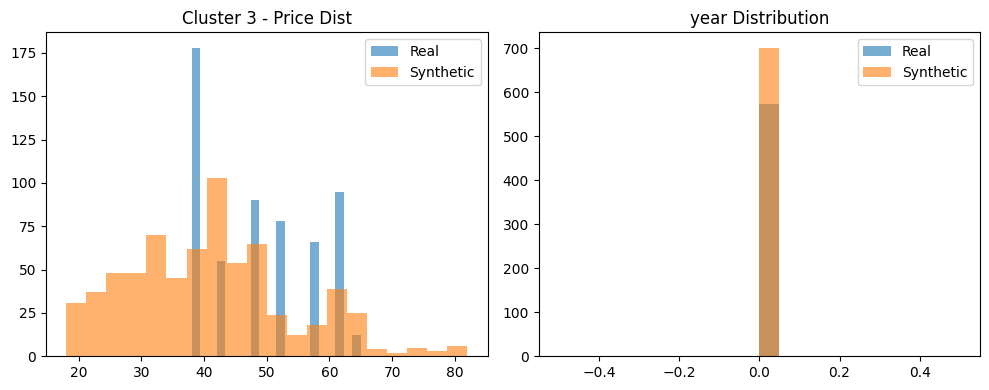


CLUSTER 4

--- Composition ---
Real samples      : 867
Synthetic samples : 1032
Real %            : 0.46
Synthetic %       : 0.54

--- Sample Real Rows ---
    year  month       day     order   country  page_1_main_category    colour  \
12   0.0   0.00  0.033333  0.054348  0.604651              1.000000  0.615385   
18   0.0   0.75  0.200000  0.038043  0.604651              0.666667  0.615385   
28   0.0   1.00  0.233333  0.000000  0.604651              1.000000  0.153846   
37   0.0   0.50  0.166667  0.005435  0.604651              0.666667  1.000000   
39   0.0   0.75  0.433333  0.038043  0.604651              0.666667  1.000000   

    location  model_photography  price_2  page  Type  Cluster  price  
12       0.8                0.0      0.0  0.25  Real        4     43  
18       1.0                0.0      0.0  0.25  Real        4     50  
28       0.0                0.0      0.0  0.00  Real        4     38  
37       0.8                0.0      0.0  0.25  Real        4     48  
3

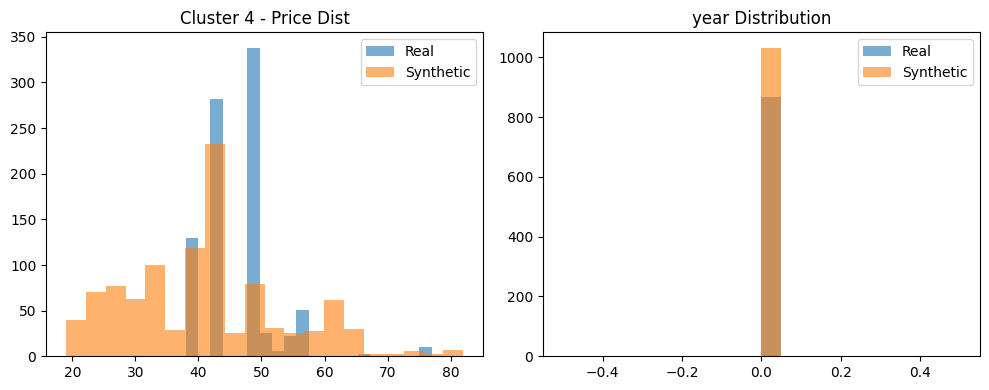

In [11]:
# ===============================
# DETAILED CLUSTER ANALYSIS
# ===============================

for cluster in sorted(combined_df["Cluster"].unique()):
    print("\n" + "="*60)
    print(f"CLUSTER {cluster}")
    print("="*60)

    cluster_data = combined_df[combined_df["Cluster"] == cluster]

    real_cluster = cluster_data[cluster_data["Type"] == "Real"]
    synth_cluster = cluster_data[cluster_data["Type"] == "Synthetic"]

    # ------------------------------
    # 1. BASIC INFO
    # ------------------------------
    print("\n--- Composition ---")
    print(f"Real samples      : {len(real_cluster)}")
    print(f"Synthetic samples : {len(synth_cluster)}")

    if len(cluster_data) > 0:
        print(f"Real %            : {len(real_cluster)/len(cluster_data):.2f}")
        print(f"Synthetic %       : {len(synth_cluster)/len(cluster_data):.2f}")

    # ------------------------------
    # 2. SAMPLE ROWS
    # ------------------------------
    print("\n--- Sample Real Rows ---")
    print(real_cluster.head(5))

    print("\n--- Sample Synthetic Rows ---")
    print(synth_cluster.head(5))

    # ------------------------------
    # 3. FEATURE COMPARISON
    # ------------------------------
    print("\n--- Feature Mean Comparison ---")
    real_mean = real_cluster[feature_cols].mean()
    synth_mean = synth_cluster[feature_cols].mean()

    comparison = pd.DataFrame({
        "Real Mean": real_mean,
        "Synthetic Mean": synth_mean,
        "Abs Diff": (real_mean - synth_mean).abs()
    })

    print(comparison.sort_values("Abs Diff", ascending=False).head(10))

    # ------------------------------
    # 4. TARGET (PRICE)
    # ------------------------------
    print("\n--- Price Distribution ---")
    print("Real:")
    print(real_cluster[target_col].describe())

    print("\nSynthetic:")
    print(synth_cluster[target_col].describe())

    # ------------------------------
    # 5. VISUAL COMPARISON
    # ------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10,4))

    # Price histogram
    axes[0].hist(real_cluster[target_col], bins=20, alpha=0.6, label="Real")
    axes[0].hist(synth_cluster[target_col], bins=20, alpha=0.6, label="Synthetic")
    axes[0].set_title(f"Cluster {cluster} - Price Dist")
    axes[0].legend()

    # One key feature (change if needed)
    feature_to_plot = feature_cols[0]

    axes[1].hist(real_cluster[feature_to_plot], bins=20, alpha=0.6, label="Real")
    axes[1].hist(synth_cluster[feature_to_plot], bins=20, alpha=0.6, label="Synthetic")
    axes[1].set_title(f"{feature_to_plot} Distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

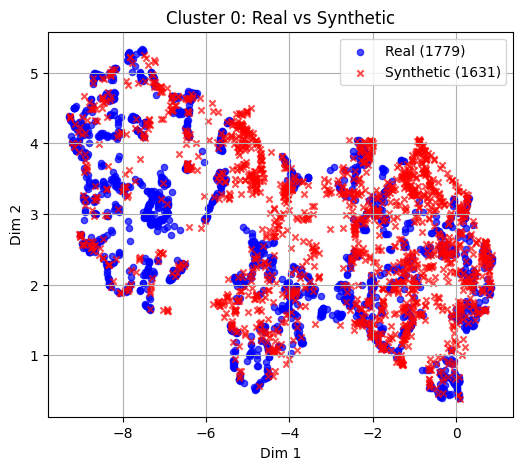

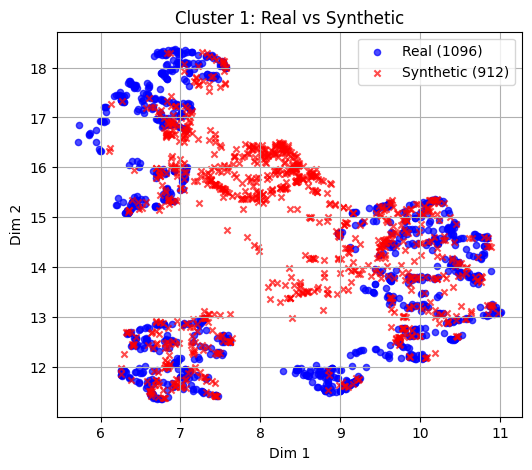

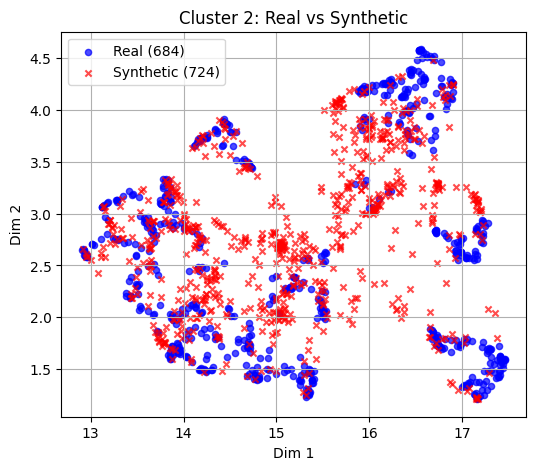

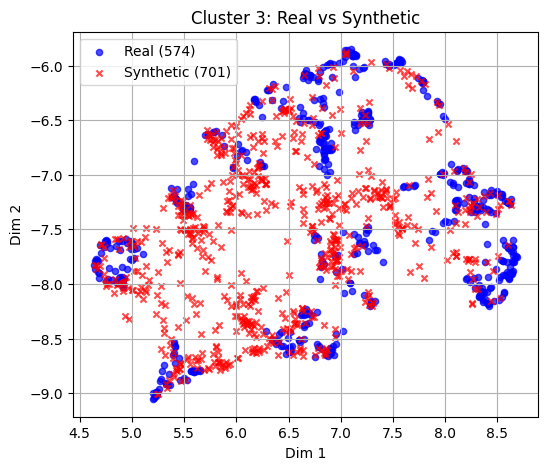

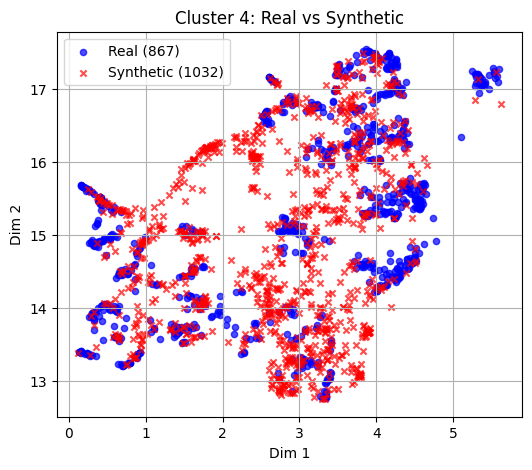

In [12]:
# ===============================
# CLUSTER-WISE VISUALIZATION
# ===============================

for cluster in sorted(combined_df["Cluster"].unique()):
    plt.figure(figsize=(6,5))

    cluster_idx = combined_df["Cluster"] == cluster

    for t, marker, color in zip(
        ["Real", "Synthetic"],
        ["o", "x"],
        ["blue", "red"]
    ):
        idx = cluster_idx & (combined_df["Type"] == t)

        plt.scatter(
            embedding[idx, 0],
            embedding[idx, 1],
            label=f"{t} ({idx.sum()})",
            alpha=0.7,
            s=20,
            marker=marker,
            c=color
        )

    plt.title(f"Cluster {cluster}: Real vs Synthetic")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend()
    plt.grid(True)
    plt.show()


=== Cluster Distribution (Real vs Synthetic) ===
Type     Real  Synthetic
Cluster                 
0        1779       1631
1        1096        912
2         684        724
3         574        701
4         867       1032

=== Cluster Purity ===
Type         Real  Synthetic
Cluster                     
0        0.521701   0.478299
1        0.545817   0.454183
2        0.485795   0.514205
3        0.450196   0.549804
4        0.456556   0.543444

=== Feature Means per Cluster ===
         year     month       day     order   country  page_1_main_category  \
Cluster                                                                       
0         0.0  0.398827  0.388133  0.058933  0.579240              0.446921   
1         0.0  0.408740  0.391152  0.054835  0.570694              0.153718   
2         0.0  0.381214  0.368561  0.058339  0.589835              0.531723   
3         0.0  0.423529  0.368967  0.064331  0.589184              0.612810   
4         0.0  0.400342  0.382798  0.06

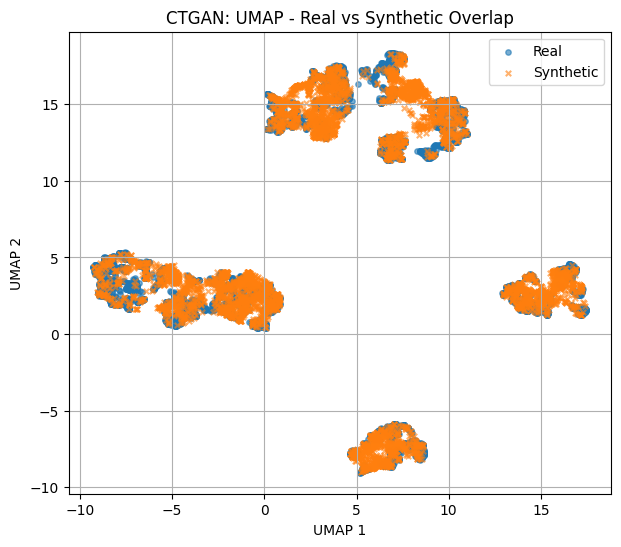

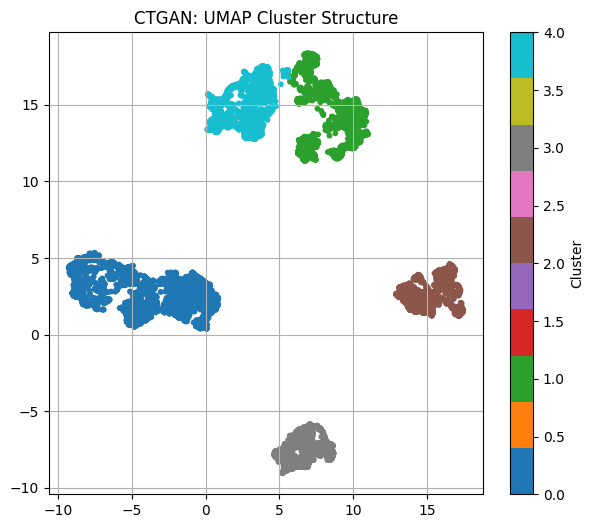

In [10]:
# ==============================
# FULL UMAP + CLUSTER ANALYSIS
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from scipy.stats import wasserstein_distance
import umap.umap_ as umap

# ------------------------------
# SETTINGS
# ------------------------------
model_name = "CTGAN"   # change model here
target_col = "price"
n_clusters = 5         # tune based on your data

# ------------------------------
# PREPARE DATA
# ------------------------------
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != target_col]

real_num = data[feature_cols].copy()
synth_df = synthetic_datasets[model_name][data.columns].copy()
synth_num = synth_df[feature_cols].copy()

scaler = MinMaxScaler()

real_scaled = scaler.fit_transform(real_num)
synth_scaled = scaler.transform(synth_num)

# Combine
combined = np.vstack([real_scaled, synth_scaled])
labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synth_scaled))

# ------------------------------
# UMAP PROJECTION
# ------------------------------
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(combined)

# ------------------------------
# CLUSTERING
# ------------------------------
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(embedding)

# ------------------------------
# BUILD ANALYSIS DATAFRAME
# ------------------------------
combined_df = pd.DataFrame(combined, columns=feature_cols)
combined_df["Type"] = labels
combined_df["Cluster"] = clusters

# Add target back
combined_df[target_col] = pd.concat([
    data[target_col].reset_index(drop=True),
    synth_df[target_col].reset_index(drop=True)
], ignore_index=True)

# ------------------------------
# CLUSTER DISTRIBUTION
# ------------------------------
print("\n=== Cluster Distribution (Real vs Synthetic) ===")
cluster_counts = pd.crosstab(combined_df["Cluster"], combined_df["Type"])
print(cluster_counts)

print("\n=== Cluster Purity ===")
cluster_purity = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)
print(cluster_purity)

# ------------------------------
# FEATURE STATISTICS
# ------------------------------
print("\n=== Feature Means per Cluster ===")
cluster_means = combined_df.groupby("Cluster")[feature_cols].mean()
print(cluster_means)

# ------------------------------
# TARGET ANALYSIS
# ------------------------------
print("\n=== Target (price) Distribution per Cluster ===")
price_summary = combined_df.groupby("Cluster")[target_col].describe()
print(price_summary)

# ------------------------------
# REAL vs SYNTH DIFFERENCE
# ------------------------------
real_df = combined_df[combined_df["Type"] == "Real"]
synth_df2 = combined_df[combined_df["Type"] == "Synthetic"]

real_means = real_df.groupby("Cluster")[feature_cols].mean()
synth_means = synth_df2.groupby("Cluster")[feature_cols].mean()

diff = (real_means - synth_means).abs()

print("\n=== Mean Difference (Real vs Synthetic) ===")
print(diff)

# ------------------------------
# WASSERSTEIN DISTANCE PER CLUSTER
# ------------------------------
print("\n=== Wasserstein Distance per Cluster ===")

wd_results = {}

for cluster in combined_df["Cluster"].unique():
    wd_cluster = {}

    real_cluster = real_df[real_df["Cluster"] == cluster]
    synth_cluster = synth_df2[synth_df2["Cluster"] == cluster]

    for col in feature_cols:
        if len(real_cluster) > 0 and len(synth_cluster) > 0:
            wd = wasserstein_distance(real_cluster[col], synth_cluster[col])
            wd_cluster[col] = wd

    wd_results[cluster] = wd_cluster

wd_df = pd.DataFrame(wd_results).T
print(wd_df)

# ------------------------------
# VISUALIZATION: REAL vs SYNTH
# ------------------------------
plt.figure(figsize=(7,6))

for t, marker, alpha in zip(["Real", "Synthetic"], ["o", "x"], [0.6, 0.6]):
    idx = combined_df["Type"] == t
    plt.scatter(
        embedding[idx, 0],
        embedding[idx, 1],
        label=t,
        alpha=alpha,
        s=15,
        marker=marker
    )

plt.title(f"{model_name}: UMAP - Real vs Synthetic Overlap")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# VISUALIZATION: CLUSTERS
# ------------------------------
plt.figure(figsize=(7,6))
plt.scatter(embedding[:,0], embedding[:,1], c=clusters, cmap="tab10", s=10)
plt.title(f"{model_name}: UMAP Cluster Structure")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

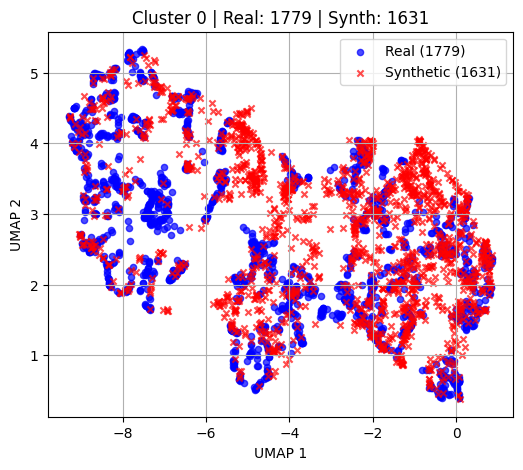

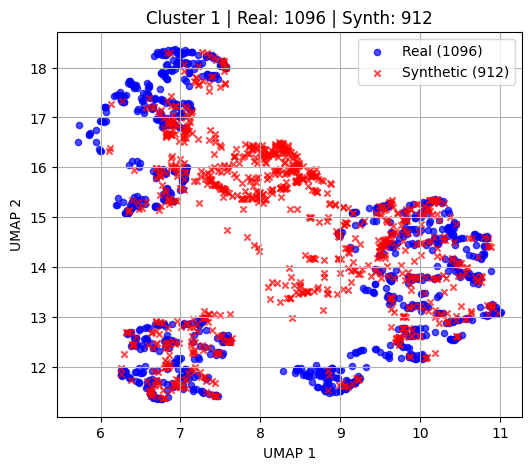

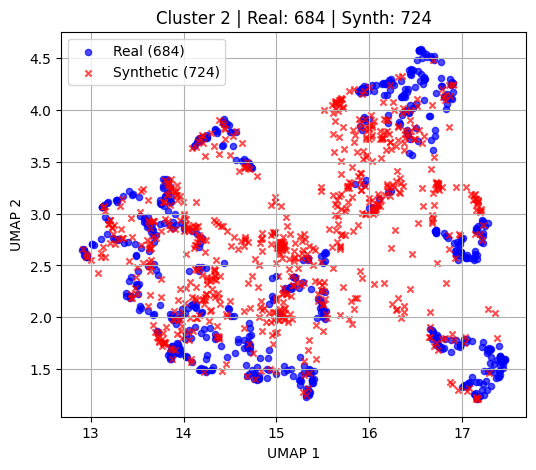

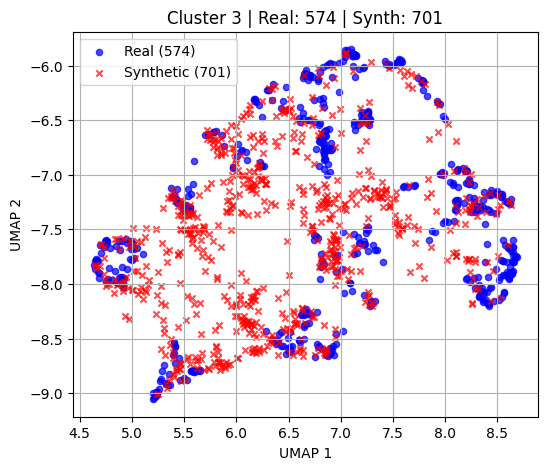

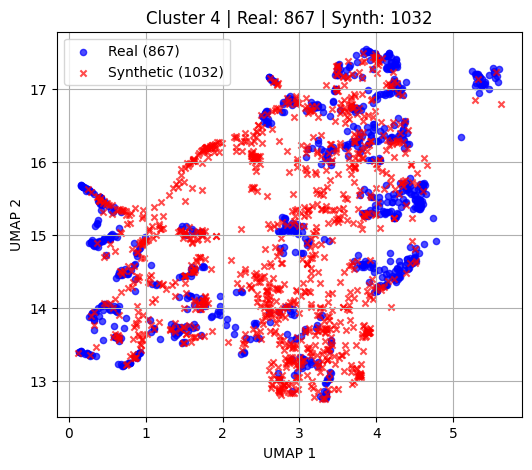

In [13]:
# ===============================
# UMAP: CLUSTER-WISE VISUALIZATION
# ===============================

for cluster in sorted(combined_df["Cluster"].unique()):
    plt.figure(figsize=(6,5))

    cluster_idx = combined_df["Cluster"] == cluster

    real_count = ((cluster_idx) & (combined_df["Type"] == "Real")).sum()
    synth_count = ((cluster_idx) & (combined_df["Type"] == "Synthetic")).sum()

    for t, marker, color in zip(
        ["Real", "Synthetic"],
        ["o", "x"],
        ["blue", "red"]
    ):
        idx = cluster_idx & (combined_df["Type"] == t)

        plt.scatter(
            embedding[idx, 0],
            embedding[idx, 1],
            label=f"{t} ({idx.sum()})",
            alpha=0.7,
            s=20,
            marker=marker,
            c=color
        )

    plt.title(f"Cluster {cluster} | Real: {real_count} | Synth: {synth_count}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend()
    plt.grid(True)
    plt.show()